In [1]:
import os
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import sys
sys.path.insert(0, '../../src')
import utils

In [2]:
# ── Configure ──────────────────────────────────────────────────────────────────
results_path = '../../outputs/pessimist/mdp_output/sensitivity_results.pt'
figures_dir  = '../../figures/pessimist/mdp_output/sensitivity'
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(figures_dir, exist_ok=True)

res = torch.load(results_path, weights_only=False)

rho_S_range      = np.array(res['rho_S_range'])       # (n_rho,)
theta_star_range = np.array(res['theta_star_range'])   # (n_theta,)
eps_star         = np.array(res['eps_star'])           # (n_rho,)
us_mdp           = np.array(res['us_mdp'])             # (n_rho,)
P_mdp            = np.array(res['P_mdp'])              # (n_rho,)
A_mdp            = np.array(res['A_mdp'])              # (n_rho,)
P_true           = np.array(res['P_true'])             # (n_rho, n_theta)
A_true           = np.array(res['A_true'])             # (n_rho, n_theta)
p_optout_true    = np.array(res['p_optout_true'])      # (n_rho, n_theta)
us_true          = np.array(res['us_true'])            # (n_rho, n_theta)
params           = res['params']

print('Parameters:')
for k, v in params.items():
    print(f'  {k}: {v}')
print(f'\nrho_S values  : {rho_S_range.tolist()}')
print(f'theta* values : {theta_star_range.tolist()}')

Parameters:
  rho_A: 240
  T: 3
  n_max: 200
  c0: 48.9
  c1: 0.066
  kappa: 0.05
  theta_b: 0.5
  alpha_0: 1.0
  beta_0: 1.5
  device: cuda
  epsilon_max: 0.9
  tol: 1e-06
  n_episodes: 200000
  theta_fid: 0.65

rho_S values  : [240.0, 500.0, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 10000.0]
theta* values : [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.85, 0.9]


## 1. Optimal subsidy $\varepsilon^*$ vs $\rho_S$

For each value of the social utility of approval $\rho_S$, Algorithm 1 (divide-and-conquer) finds the subsidy $\varepsilon^*$ that maximises the principal's expected social utility $U^S = \rho_S P_{\text{approval}} - \varepsilon^* A$ under the MDP's Beta-Binomial dynamics.

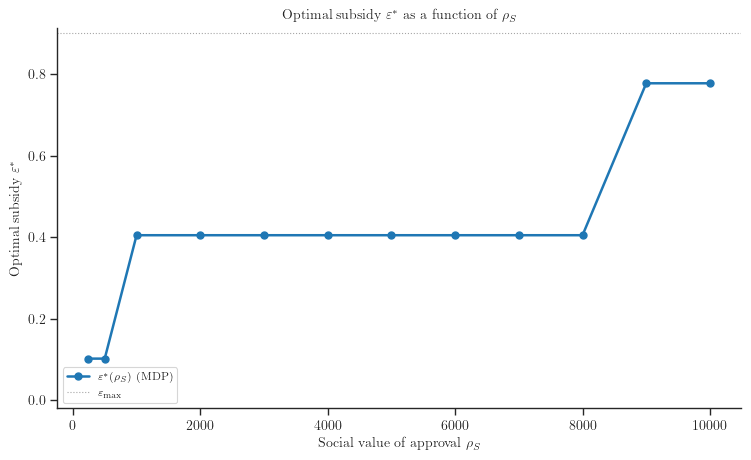

In [3]:
sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 1000
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

palette = sns.color_palette('tab10')

ax.plot(rho_S_range, eps_star, 'o-', color=palette[0],
        linewidth=1.8, markersize=5, label=r'$\varepsilon^*(\rho_S)$ (MDP)')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'Optimal subsidy $\varepsilon^*$')
ax.set_title(r'Optimal subsidy $\varepsilon^*$ as a function of $\rho_S$')
ax.set_ylim(-0.02, max(eps_star) * 1.15 + 0.02)

# Reference line at epsilon_max
epsilon_max = float(params.get('epsilon_max', 1.0))
ax.axhline(epsilon_max, color='gray', lw=0.8, ls=':', alpha=0.7,
           label=r'$\varepsilon_{\max}$')

ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 2. MDP social utility $U^S_{\text{MDP}}$ vs $\rho_S$

Social utility under the MDP (Beta-Binomial) dynamics at the optimal subsidy.

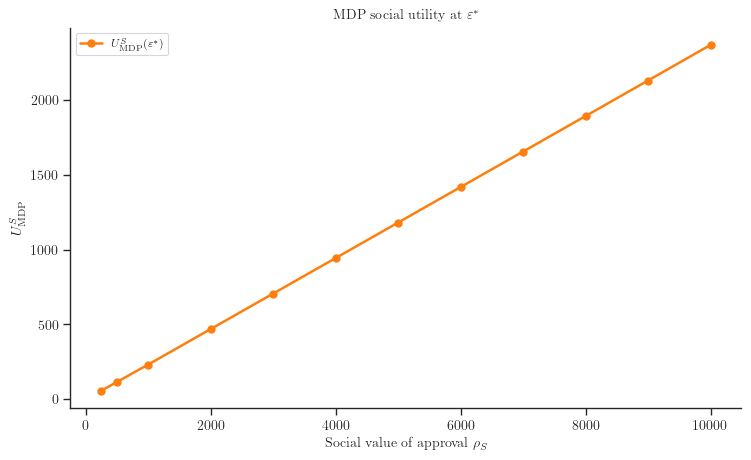

In [4]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

ax.plot(rho_S_range, us_mdp, 'o-', color=palette[1],
        linewidth=1.8, markersize=5, label=r'$U^S_{\mathrm{MDP}}(\varepsilon^*)$')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'$U^S_{\mathrm{MDP}}$')
ax.set_title(r'MDP social utility at $\varepsilon^*$')
ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'us_mdp_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'us_mdp_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 3. True social utility $U^S_{\text{true}}$ vs $\rho_S$ (one curve per $\theta^*$)

For each $\theta^*$, the true social utility at the MDP-optimal subsidy $\varepsilon^*(\rho_S)$ is
$$
U^S_{\text{true}}(\varepsilon^*;\pi^*,\theta^*) = \rho_S\,P_{\text{true}}(\theta^*) - \varepsilon^* A_{\text{true}}(\theta^*)
$$
estimated via Monte Carlo under Binomial$(n, \theta^*)$ rollouts.

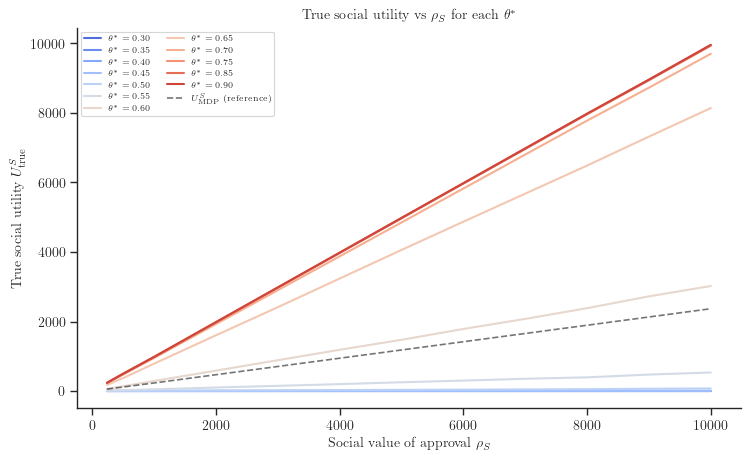

In [5]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

colors_theta = sns.color_palette('coolwarm', len(theta_star_range))

for j, theta_star in enumerate(theta_star_range):
    ax.plot(rho_S_range, us_true[:, j],
            color=colors_theta[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

# Overlay MDP social utility for comparison
ax.plot(rho_S_range, us_mdp, 'k--', linewidth=1.2, alpha=0.6,
        label=r'$U^S_{\mathrm{MDP}}$ (reference)')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'True social utility $U^S_{\mathrm{true}}$')
ax.set_title(r'True social utility vs $\rho_S$ for each $\theta^*$')
ax.legend(fontsize=6, ncol=2, loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'us_true_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'us_true_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 4. True opt-out probability (before approval) vs $\rho_S$ (one curve per $\theta^*$)

$P_{\theta^*}(\text{agent opts out before approval})$ under the MDP-optimal policy at $\varepsilon^*(\rho_S)$, evaluated via Monte Carlo rollouts.

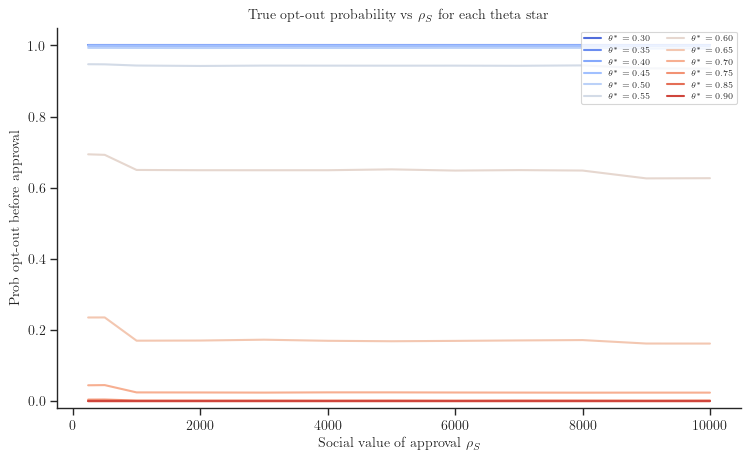

In [6]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for j, theta_star in enumerate(theta_star_range):
    ax.plot(rho_S_range, p_optout_true[:, j],
            color=colors_theta[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'Prob opt-out before approval')
ax.set_title(r'True opt-out probability vs $\rho_S$ for each theta star')
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=6, ncol=2, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'p_optout_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'p_optout_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 5. True approval probability $P_{\text{true}}$ vs $\rho_S$ (one curve per $\theta^*$)

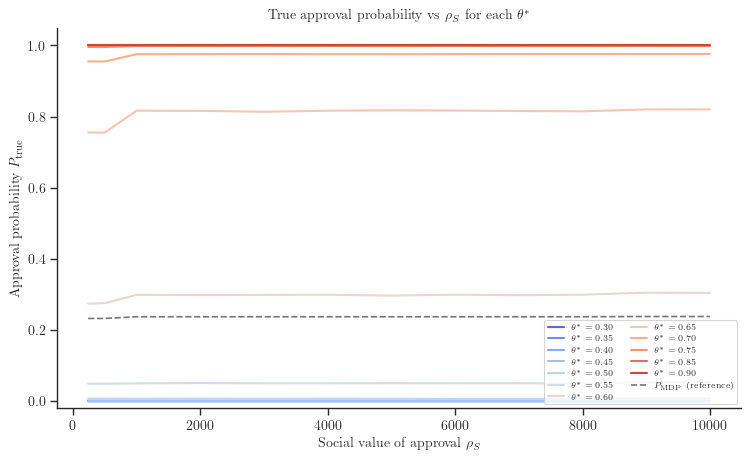

In [7]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for j, theta_star in enumerate(theta_star_range):
    ax.plot(rho_S_range, P_true[:, j],
            color=colors_theta[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

# MDP approval probability for reference
ax.plot(rho_S_range, P_mdp, 'k--', linewidth=1.2, alpha=0.6,
        label=r'$P_{\mathrm{MDP}}$ (reference)')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'Approval probability $P_{\mathrm{true}}$')
ax.set_title(r'True approval probability vs $\rho_S$ for each $\theta^*$')
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=6, ncol=2, loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'P_true_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'P_true_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 6. Summary table

In [8]:
print(f"{'rho_S':>8}  {'eps*':>8}  {'U^S_mdp':>10}  {'P_mdp':>7}  {'A_mdp':>7}")
print('-' * 50)
for i, rho_S in enumerate(rho_S_range):
    print(f"{rho_S:8.1f}  {eps_star[i]:8.4f}  {us_mdp[i]:10.2f}  "
          f"{P_mdp[i]:7.4f}  {A_mdp[i]:7.2f}")

   rho_S      eps*     U^S_mdp    P_mdp    A_mdp
--------------------------------------------------
   240.0    0.1019       54.33   0.2326    14.59
   500.0    0.1019      114.80   0.2326    14.59
  1000.0    0.4046      231.16   0.2373    15.27
  2000.0    0.4046      468.51   0.2373    15.27
  3000.0    0.4046      705.85   0.2373    15.27
  4000.0    0.4046      943.19   0.2373    15.27
  5000.0    0.4046     1180.53   0.2373    15.27
  6000.0    0.4046     1417.88   0.2373    15.27
  7000.0    0.4046     1655.22   0.2373    15.27
  8000.0    0.4046     1892.56   0.2373    15.27
  9000.0    0.7774     2130.22   0.2380    15.50
 10000.0    0.7774     2368.25   0.2380    15.50


/tmp/ipykernel_3110368/919085950.py:45: RuntimeWarning: divide by zero encountered in divide
  return np.where(np.abs(den) > 1e-12, (num - den) / den * 100.0, np.nan)
/tmp/ipykernel_3110368/919085950.py:90: RuntimeWarning: divide by zero encountered in divide
  pa = np.where(np.abs(m_ss0)   > 1e-12, (m_true - m_ss0)   / m_ss0   * 100.0, np.nan)
/NL/strategic-experiments/work/venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1573: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


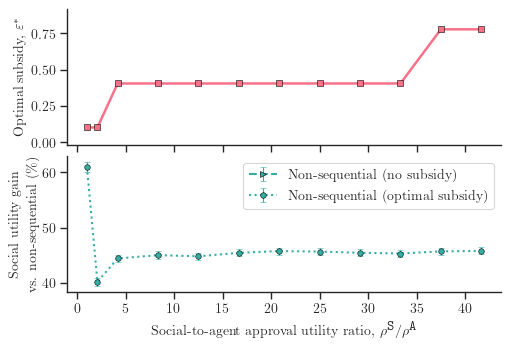


   rho_S   rho_S/rho_A        eps*     eps*_ss     gain_vs_ss0_%     gain_vs_ssopt_%
--------------------------------------------------------------------------------
   240.0         1.000      0.1019      0.3530               nan               60.93
   500.0         2.083      0.1019      0.4957               nan               40.26
  1000.0         4.167      0.4046      0.4957               nan               44.45
  2000.0         8.333      0.4046      0.4957               nan               45.05
  3000.0        12.500      0.4046      0.4957               nan               44.84
  4000.0        16.667      0.4046      0.4957               nan               45.47
  5000.0        20.833      0.4046      0.4957               nan               45.78
  6000.0        25.000      0.4046      0.4957               nan               45.69
  7000.0        29.167      0.4046      0.4957               nan               45.48
  8000.0        33.333      0.4046      0.4957               nan    

In [9]:
# ── Combined plot: epsilon* (top) + %-gain vs non-sequential baseline (bottom) ──
sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 750
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(fig_width, fig_height),
                                      sharex=True,
                                      gridspec_kw={'hspace': 0.08})

palette = sns.color_palette('husl', n_colors=4)

rho_A_val = float(params['rho_A'])
x_ratio = rho_S_range / rho_A_val

# ── Top panel: optimal subsidy ──────────────────────────────────────────────
ax_top.plot(x_ratio, eps_star, 's-', color=palette[0],
            linewidth=1.8, markersize=5, label=r'$\varepsilon^*(\rho_S)$ (MDP)',
            markeredgecolor='black', markeredgewidth=0.4)
ax_top.set_ylabel(r'Optimal subsidy, $\varepsilon^*$', fontsize=10)
ax_top.set_ylim(-0.02, max(eps_star) * 1.15 + 0.02)
ax_top.tick_params(axis='both', labelsize=10)
sns.despine(ax=ax_top)

# ── Load single-shot baseline for this setting ──────────────────────────────
ss_path = '../../outputs/single_shot/pessimist/single_shot_baseline.pt'
ss = torch.load(ss_path, weights_only=False)
assert ss['rho_S_range']      == rho_S_range.tolist()
assert ss['theta_star_range'] == theta_star_range.tolist()

us_ss0_    = np.array(ss['us_true_ss0'])
us_ssopt_  = np.array(ss['us_true_ss_epsopt'])
P_ss0_     = np.array(ss['P_true_ss0'])
A_ss0_     = np.array(ss['A_true_ss0'])
P_ssopt_   = np.array(ss['P_true_ss_epsopt'])
A_ssopt_   = np.array(ss['A_true_ss_epsopt'])
eps_ss_opt = np.array(ss['eps_ss_opt'])

theta_fid = 0.65
j_fid = int(np.argmin(np.abs(theta_star_range - theta_fid)))
assert abs(theta_star_range[j_fid] - theta_fid) < 1e-9, \
    f'theta*=0.65 not in theta_star_range: {theta_star_range.tolist()}'

def _pct_gain(num, den):
    return np.where(np.abs(den) > 1e-12, (num - den) / den * 100.0, np.nan)

pct_a = _pct_gain(us_true[:, j_fid], us_ss0_[:,   j_fid])
pct_b = _pct_gain(us_true[:, j_fid], us_ssopt_[:, j_fid])

# ── Bootstrap 95% CIs if per-episode samples are available ──────────────────
have_fid_samples = ('samples_fid_approved' in res and 'samples_fid_cost' in res)
have_ss_samples  = ('samples_ss0_approved' in ss and 'samples_ssopt_approved' in ss
                    and 'samples_ssopt_cost' in ss)
use_ci = have_fid_samples and have_ss_samples

yerr_a = None
yerr_b = None
if use_ci:
    _fid_ap = np.asarray(res['samples_fid_approved'])
    _fid_co = np.asarray(res['samples_fid_cost']).astype(np.float64)
    _ss0_ap = np.asarray(ss['samples_ss0_approved'])
    _sso_ap = np.asarray(ss['samples_ssopt_approved'])
    _sso_co = np.asarray(ss['samples_ssopt_cost']).astype(np.float64)

    n_rho_   = len(rho_S_range)
    B        = 1000
    batch    = 50
    boot_rng = np.random.default_rng(0)

    def _boot_means(samples_1d, B, batch, rng):
        n = len(samples_1d); out = np.empty(B)
        for s in range(0, B, batch):
            e = min(s + batch, B)
            idx = rng.integers(0, n, size=(e - s, n))
            out[s:e] = samples_1d[idx].mean(axis=1)
        return out

    pct_a_lo = np.full(n_rho_, np.nan); pct_a_hi = np.full(n_rho_, np.nan)
    pct_b_lo = np.full(n_rho_, np.nan); pct_b_hi = np.full(n_rho_, np.nan)
    for i_ in range(n_rho_):
        rho_S_i   = rho_S_range[i_]
        eps_fid_i = eps_star[i_]
        eps_sso_i = eps_ss_opt[i_]
        u_true_s  = rho_S_i * _fid_ap[i_].astype(np.float64) - eps_fid_i * _fid_co[i_]
        u_ss0_s   = rho_S_i * _ss0_ap.astype(np.float64)
        u_ssopt_s = rho_S_i * _sso_ap[i_].astype(np.float64) - eps_sso_i * _sso_co[i_]
        m_true  = _boot_means(u_true_s,  B, batch, boot_rng)
        m_ss0   = _boot_means(u_ss0_s,   B, batch, boot_rng)
        m_ssopt = _boot_means(u_ssopt_s, B, batch, boot_rng)
        pa = np.where(np.abs(m_ss0)   > 1e-12, (m_true - m_ss0)   / m_ss0   * 100.0, np.nan)
        pb = np.where(np.abs(m_ssopt) > 1e-12, (m_true - m_ssopt) / m_ssopt * 100.0, np.nan)
        pct_a_lo[i_], pct_a_hi[i_] = np.nanquantile(pa, [0.025, 0.975])
        pct_b_lo[i_], pct_b_hi[i_] = np.nanquantile(pb, [0.025, 0.975])
    yerr_a = np.vstack([pct_a - pct_a_lo, pct_a_hi - pct_a])
    yerr_b = np.vstack([pct_b - pct_b_lo, pct_b_hi - pct_b])
else:
    print('[info] per-episode samples missing — plotting point estimates without CIs')

# ── Bottom panel: % utility gain ────────────────────────────────────────────
ax_bot.errorbar(x_ratio, pct_a, yerr=yerr_a, fmt='>--', color=palette[2],
                linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                label=r'Non-sequential (no subsidy)')
ax_bot.errorbar(x_ratio, pct_b, yerr=yerr_b, fmt='o:', color=palette[2],
                linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                label=r'Non-sequential (optimal subsidy)')

ax_bot.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=10)
ax_bot.set_ylabel(
    r'$\begin{array}{c}\textrm{Social utility gain} \\ \textrm{vs. non-sequential}\ (\%)\end{array}$',
    fontsize=10, labelpad=12, rotation=90, va='center')
ax_bot.legend(fontsize=10, loc='best')
sns.despine(ax=ax_bot)

fig.subplots_adjust(left=0.12, right=0.88, top=0.95, bottom=0.15)
plt.show()
fig.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS_vs_ss.pdf'))

print(f"\n{'rho_S':>8}  {'rho_S/rho_A':>12}  {'eps*':>10}  {'eps*_ss':>10}  {'gain_vs_ss0_%':>16}  {'gain_vs_ssopt_%':>18}")
print('-' * 80)
for i, rho_S in enumerate(rho_S_range):
    print(f"{rho_S:8.1f}  {x_ratio[i]:12.3f}  {eps_star[i]:10.4f}  {eps_ss_opt[i]:10.4f}  {pct_a[i]:16.2f}  {pct_b[i]:18.2f}")


In [10]:
width_pt = 1000
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.65)

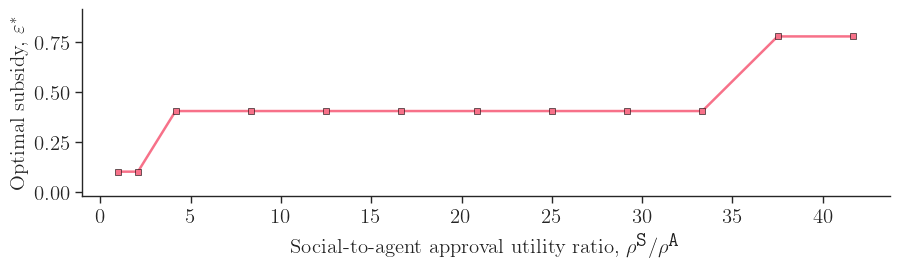

In [11]:
# ── Panel A only: optimal subsidy epsilon* vs rho_S/rho_A ────────────────────
fig_top, ax_top_only = plt.subplots(figsize=(fig_width, fig_height / 2))

ax_top_only.plot(x_ratio, eps_star, 's-', color=palette[0],
                 linewidth=1.8, markersize=5, label=r'$\varepsilon^*(\rho_S)$ (MDP)',
                 markeredgecolor='black', markeredgewidth=0.4)
ax_top_only.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=15)
ax_top_only.set_ylabel(r'Optimal subsidy, $\varepsilon^*$', fontsize=15)
ax_top_only.set_ylim(-0.02, max(eps_star) * 1.15 + 0.02)
ax_top_only.tick_params(axis='both', labelsize=15)
sns.despine(ax=ax_top_only)
fig_top.tight_layout()
plt.show()
fig_top.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS_top.pdf'), bbox_inches='tight')


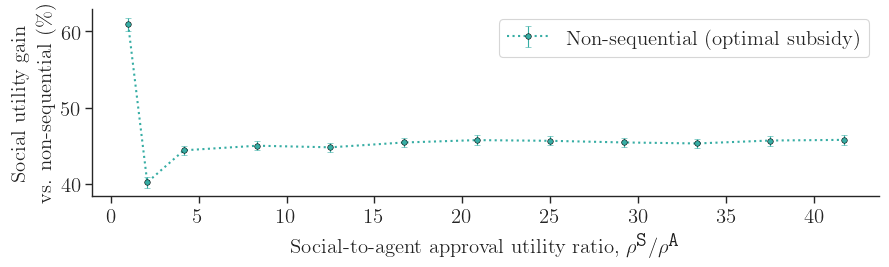

In [14]:
# ── Panel B only: % social utility gain vs non-sequential baseline ──────────
fig_bot, ax_bot_only = plt.subplots(figsize=(fig_width, fig_height / 2))

label_a = r'Non-sequential (no subsidy)' if not np.any(np.isnan(pct_a)) else '_nolegend_'
ax_bot_only.errorbar(x_ratio, pct_a, yerr=yerr_a, fmt='>--', color=palette[2],
                     linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                     ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                     label=label_a)
ax_bot_only.errorbar(x_ratio, pct_b, yerr=yerr_b, fmt='o:', color=palette[2],
                     linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                     ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                     label=r'Non-sequential (optimal subsidy)')

ax_bot_only.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=15)
ax_bot_only.set_ylabel(
    r'$\begin{array}{c}\textrm{Social utility gain} \\ \textrm{vs. non-sequential}\ (\%)\end{array}$',
    fontsize=15, labelpad=20, rotation=90, va='center')
ax_bot_only.tick_params(axis='both', labelsize=15)
ax_bot_only.legend(fontsize=15, loc='best')
sns.despine(ax=ax_bot_only)
fig_bot.tight_layout()
plt.show()
fig_bot.savefig(os.path.join(figures_dir, 'pct_gain_vs_rhoS_bot.pdf'), bbox_inches='tight')


In [13]:
c0 = float(params['c0']); c1 = float(params['c1'])

def _recover_n_star(A_row, P_row):
    p = P_row[j_fid]; a = A_row[j_fid]
    if p <= 0:
        return float('nan')
    return (a / p - c0) / c1

n_star_ss0   = np.array([_recover_n_star(A_ss0_[i],   P_ss0_[i])   for i in range(len(rho_S_range))])
n_star_ssopt = np.array([_recover_n_star(A_ssopt_[i], P_ssopt_[i]) for i in range(len(rho_S_range))])

n_max_ss = int(ss['params']['n_max'])
print(f"Single-shot n_max = {n_max_ss}   rho_A = {rho_A_val}")
print(f"{'rho_S':>8}  {'rho_S/rho_A':>12}  {'eps*_fid':>10}  {'eps*_ss':>10}  {'n* (eps=0)':>11}  {'n* (eps=eps*_ss)':>18}")
print('-' * 80)
for i, rho_S in enumerate(rho_S_range):
    print(f"{rho_S:8.1f}  {x_ratio[i]:12.3f}  {eps_star[i]:10.4f}  {eps_ss_opt[i]:10.4f}  "
          f"{n_star_ss0[i]:11.2f}  {n_star_ssopt[i]:18.2f}")

Single-shot n_max = 800   rho_A = 240.0
   rho_S   rho_S/rho_A    eps*_fid     eps*_ss   n* (eps=0)    n* (eps=eps*_ss)
--------------------------------------------------------------------------------
   240.0         1.000      0.1019      0.3530          nan               79.00
   500.0         2.083      0.1019      0.4957          nan              108.00
  1000.0         4.167      0.4046      0.4957          nan              108.00
  2000.0         8.333      0.4046      0.4957          nan              108.00
  3000.0        12.500      0.4046      0.4957          nan              108.00
  4000.0        16.667      0.4046      0.4957          nan              108.00
  5000.0        20.833      0.4046      0.4957          nan              108.00
  6000.0        25.000      0.4046      0.4957          nan              108.00
  7000.0        29.167      0.4046      0.4957          nan              108.00
  8000.0        33.333      0.4046      0.4957          nan              108.00